# Performance Estimation & Benchmark Results

Set `WORKLOAD` below to select which input/output configuration to view.

In [14]:
import json
import glob
import os
import pandas as pd

# ─── Select workload ───────────────────────────────────────────────
WORKLOAD = "in763-out232"  # Change this to view different workloads
# ───────────────────────────────────────────────────────────────────

BASE_DIR = os.path.dirname(os.path.abspath("__file__"))
EST_DIR = os.path.join(BASE_DIR, WORKLOAD, "results", "data", "estimated")
MEAS_DIR = os.path.join(BASE_DIR, WORKLOAD, "results", "data", "measured")

available = sorted([
    d for d in os.listdir(BASE_DIR)
    if d.startswith("in") and "-out" in d and os.path.isdir(os.path.join(BASE_DIR, d))
])
print(f"Available workloads: {available}")
print(f"Selected: {WORKLOAD}")

Available workloads: ['in763-out232']
Selected: in763-out232


## Helper Functions

In [15]:
COLS = ["ttft_ms", "tpot_ms", "e2e_ms", "rps"]


def load_estimated(est_dir: str = EST_DIR) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(est_dir, "est_*.json")))
    rows = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        if not d.get("feasible", False):
            continue
        for entry in d.get("batch_sweep", []):
            rows.append({
                "instance": d["instance_type"],
                "tp": d["tp_size"],
                "pp": d["pp_size"],
                "batch": entry["batch_size"],
                "ttft_ms": round(entry.get("ttft_ms", 0), 2),
                "tpot_ms": round(entry.get("tpot_ms", 0), 4),
                "e2e_ms": round(entry["batch_latency_ms"], 2),
                "rps": round(entry["throughput_rps"], 4),
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["instance", "tp", "pp", "batch"]).reset_index(drop=True)
    return df


def load_measured(meas_dir: str = MEAS_DIR) -> pd.DataFrame:
    files = sorted(glob.glob(os.path.join(meas_dir, "bench_*.json")))
    rows = []
    for f in files:
        with open(f) as fp:
            d = json.load(fp)
        for entry in d.get("batch_sweep", []):
            rows.append({
                "instance": d["instance_type"],
                "tp": d["tp_size"],
                "pp": d["pp_size"],
                "batch": entry["batch_size"],
                "ttft_ms": round(entry["mean_ttft_ms"], 2),
                "tpot_ms": round(entry["mean_tpot_ms"], 4),
                "e2e_ms": round(entry["mean_e2el_ms"], 2),
                "rps": round(entry["request_throughput"], 4),
                "completed": entry["completed"],
            })
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["instance", "tp", "pp", "batch"]).reset_index(drop=True)
    return df


JOIN_KEYS = ["instance", "tp", "pp", "batch"]


def merge_est_meas(est_df, meas_df) -> pd.DataFrame:
    merged = pd.merge(est_df, meas_df, on=JOIN_KEYS, suffixes=("_est", "_meas"))
    return merged.sort_values(JOIN_KEYS).reset_index(drop=True)


def compute_mape(merged_df) -> pd.DataFrame:
    """MAPE per (instance, tp, pp). Result in %."""
    def _mape(g):
        return pd.Series({
            f"{c}_mape%": ((g[f"{c}_est"] - g[f"{c}_meas"]).abs() / g[f"{c}_meas"].abs().clip(lower=1e-9) * 100).mean()
            for c in COLS
        })
    return merged_df.groupby(["instance", "tp", "pp"]).apply(_mape).round(2).reset_index()


def compute_overall_mape(merged_df) -> pd.Series:
    """Overall MAPE in %."""
    result = pd.Series({
        f"{c}_mape%": ((merged_df[f"{c}_est"] - merged_df[f"{c}_meas"]).abs() / merged_df[f"{c}_meas"].abs().clip(lower=1e-9) * 100).mean()
        for c in COLS
    })
    return result.round(2)


def filter_df(df, instance=None, tp=None, pp=None):
    if instance:
        df = df[df["instance"] == instance]
    if tp:
        df = df[df["tp"] == tp]
    if pp:
        df = df[df["pp"] == pp]
    return df.reset_index(drop=True)


def max_batch_summary(df):
    return (
        df.loc[df.groupby(["instance", "tp", "pp"])["batch"].idxmax()]
        .sort_values(["instance", "tp", "pp"])
        .reset_index(drop=True)
    )

---
## 1. Estimated

In [16]:
est_df = load_estimated()
print(f"Estimated: {len(est_df)} rows, {est_df.groupby(['instance','tp','pp']).ngroups} configs")
max_batch_summary(est_df)

Estimated: 164 rows, 18 configs


,instance,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps
0,g5.48xlarge,2,4,11,2857.01,11.1498,31311.29,0.3513
1,g5.48xlarge,4,2,30,10427.41,2.2252,25914.68,1.1576
2,g5.48xlarge,8,1,33,16907.53,1.3648,27356.64,1.2063
3,g6.48xlarge,2,4,11,1926.46,22.2222,58637.61,0.1876
4,g6.48xlarge,4,2,30,7961.96,4.2504,37544.48,0.7991
5,g6.48xlarge,8,1,33,14235.36,2.3099,31920.33,1.0338
6,g6e.48xlarge,1,8,443,18174.17,0.4459,63999.20,6.9220
7,g6e.48xlarge,2,4,481,47057.33,0.2968,80181.29,5.9989
8,g6e.48xlarge,4,2,499,94961.40,0.3272,132844.52,3.7563
9,g6e.48xlarge,8,1,502,179405.71,0.5097,238769.93,2.1024


---
## 2. Measured

In [17]:
meas_df = load_measured()
if meas_df.empty:
    print("No measured data yet.")
else:
    # Join with estimated to compute MAPE
    meas_with_mape = pd.merge(meas_df, est_df, on=JOIN_KEYS, suffixes=('', '_est'))
    for c in COLS:
        meas_with_mape[f"{c}_mape%"] = ((meas_with_mape[f"{c}_est"] - meas_with_mape[c]).abs() / meas_with_mape[c].abs().clip(lower=1e-9) * 100).round(2)
    drop_cols = [f"{c}_est" for c in COLS]
    meas_with_mape = meas_with_mape.drop(columns=drop_cols)
    print(f"Measured: {len(meas_df)} rows, {meas_df.groupby(['instance','tp','pp']).ngroups} configs")
    display(max_batch_summary(meas_with_mape))

Measured: 84 rows, 13 configs


,instance,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps,completed,ttft_ms_mape%,tpot_ms_mape%,e2e_ms_mape%,rps_mape%
0,g5.48xlarge,2,4,8,8577.83,452.8519,113186.61,0.1413,80,75.78,96.63,73.11,86.06
1,g5.48xlarge,4,2,16,20641.83,398.2837,112645.36,0.2838,160,73.06,99.01,82.08,179.28
2,g5.48xlarge,8,1,32,80080.03,1088.9161,331619.64,0.1916,320,79.53,99.87,91.94,524.79
3,g6.48xlarge,2,4,8,4757.32,671.1135,159784.54,0.1001,80,70.55,95.46,63.72,37.86
4,g6.48xlarge,4,2,16,8148.55,405.5404,101828.39,0.3139,160,47.89,98.11,67.83,55.62
5,g6.48xlarge,8,1,33,27614.75,575.3216,160514.04,0.3996,330,48.45,99.60,80.11,158.71
6,g6e.48xlarge,2,4,128,20732.83,615.7065,162961.04,1.5586,1280,39.60,99.87,78.12,130.33
7,g6e.48xlarge,4,2,128,32470.25,713.2620,197233.77,1.2897,1280,24.98,99.92,79.15,141.37
8,g6e.48xlarge,8,1,128,78684.03,1413.8172,405275.79,0.6295,1280,41.86,99.96,84.14,216.39
9,p4d.24xlarge,1,8,64,4339.89,356.1205,86603.72,1.4683,640,29.80,99.56,69.58,65.45


---
## 3. Estimated vs Measured

`*_ae` = |estimated − measured|

In [18]:
if not meas_df.empty:
    merged = merge_est_meas(est_df, meas_df)
    print(f"Matched: {len(merged)} rows")
    display(merged)
else:
    print("No measured data to compare.")

Matched: 84 rows


,instance,tp,pp,batch,ttft_ms_est,tpot_ms_est,e2e_ms_est,rps_est,ttft_ms_meas,tpot_ms_meas,e2e_ms_meas,rps_meas,completed
0,g5.48xlarge,2,4,1,1038.91,121.6562,29263.15,0.0342,2329.29,331.3329,78867.19,0.0254,10
1,g5.48xlarge,2,4,2,1038.91,60.8281,29263.15,0.0683,3857.69,345.8765,83755.15,0.0477,20
2,g5.48xlarge,2,4,4,1038.91,30.4140,29263.15,0.1367,3559.53,390.4137,93745.10,0.0853,40
3,g5.48xlarge,2,4,8,2077.83,15.2778,30433.51,0.2629,8577.83,452.8519,113186.61,0.1413,80
4,g5.48xlarge,4,2,1,695.16,59.5075,14500.90,0.0690,3135.48,215.8638,53000.01,0.0377,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,p4d.24xlarge,8,1,16,924.33,0.7437,3684.82,4.3421,1205.69,113.1036,27332.61,1.1632,160
80,p4d.24xlarge,8,1,32,1848.65,0.3945,4777.29,6.6984,1831.60,127.6058,31308.54,2.0215,320
81,p4d.24xlarge,8,1,64,3697.30,0.2199,6962.23,9.1925,2933.17,151.5157,37933.29,3.3129,640
82,p4d.24xlarge,8,1,128,7394.61,0.1326,11332.12,11.2953,5174.17,203.5504,52194.31,4.7760,1280


### 3a. MAPE per Config (%)

In [19]:
if not meas_df.empty:
    display(compute_mape(merged))

,instance,tp,pp,ttft_ms_mape%,tpot_ms_mape%,e2e_ms_mape%,rps_mape%
0,g5.48xlarge,2,4,68.76,83.63,67.46,56.04
1,g5.48xlarge,4,2,77.90,89.83,76.67,119.85
2,g5.48xlarge,8,1,82.72,93.27,84.95,281.48
3,g6.48xlarge,2,4,66.43,80.25,59.62,24.40
4,g6.48xlarge,4,2,53.84,85.16,63.75,38.91
5,g6.48xlarge,8,1,57.79,90.76,72.89,95.10
6,g6e.48xlarge,2,4,53.05,99.22,74.01,96.29
7,g6e.48xlarge,4,2,49.00,93.00,73.77,95.23
8,g6e.48xlarge,8,1,57.96,94.73,80.81,167.51
9,p4d.24xlarge,1,8,45.69,87.95,62.31,35.67


### 3b. Overall MAPE

In [20]:
if not meas_df.empty:
    overall = compute_overall_mape(merged)
    print("Overall MAPE:")
    for k, v in overall.items():
        print(f"  {k}: {v}%")

Overall MAPE:
  ttft_ms_mape%: 55.5%
  tpot_ms_mape%: 91.92%
  e2e_ms_mape%: 74.38%
  rps_mape%: 125.04%


### 3c. Config Summary (max batch)

In [21]:
if not meas_df.empty:
    summary = merged[["instance", "tp", "pp", "batch"]].copy()
    for c in COLS:
        summary[f"{c}_est"] = merged[f"{c}_est"].values
        summary[f"{c}_meas"] = merged[f"{c}_meas"].values
        meas_vals = merged[f"{c}_meas"].values
        summary[f"{c}_mape%"] = (abs(merged[f"{c}_est"].values - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100).round(2)
    display(summary)

,instance,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,g5.48xlarge,2,4,1,1038.91,2329.29,55.40,121.6562,331.3329,63.28,29263.15,78867.19,62.90,0.0342,0.0254,34.65
1,g5.48xlarge,2,4,2,1038.91,3857.69,73.07,60.8281,345.8765,82.41,29263.15,83755.15,65.06,0.0683,0.0477,43.19
2,g5.48xlarge,2,4,4,1038.91,3559.53,70.81,30.4140,390.4137,92.21,29263.15,93745.10,68.78,0.1367,0.0853,60.26
3,g5.48xlarge,2,4,8,2077.83,8577.83,75.78,15.2778,452.8519,96.63,30433.51,113186.61,73.11,0.2629,0.1413,86.06
4,g5.48xlarge,4,2,1,695.16,3135.48,77.83,59.5075,215.8638,72.43,14500.90,53000.01,72.64,0.0690,0.0377,83.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,p4d.24xlarge,8,1,16,924.33,1205.69,23.34,0.7437,113.1036,99.34,3684.82,27332.61,86.52,4.3421,1.1632,273.29
80,p4d.24xlarge,8,1,32,1848.65,1831.60,0.93,0.3945,127.6058,99.69,4777.29,31308.54,84.74,6.6984,2.0215,231.36
81,p4d.24xlarge,8,1,64,3697.30,2933.17,26.05,0.2199,151.5157,99.85,6962.23,37933.29,81.65,9.1925,3.3129,177.48
82,p4d.24xlarge,8,1,128,7394.61,5174.17,42.91,0.1326,203.5504,99.93,11332.12,52194.31,78.29,11.2953,4.7760,136.50


---
## 5. Estimated vs Measured Bar Charts

Per instance × strategy, across all batch sizes.  
Left: raw values. Right: normalized to batch=1.

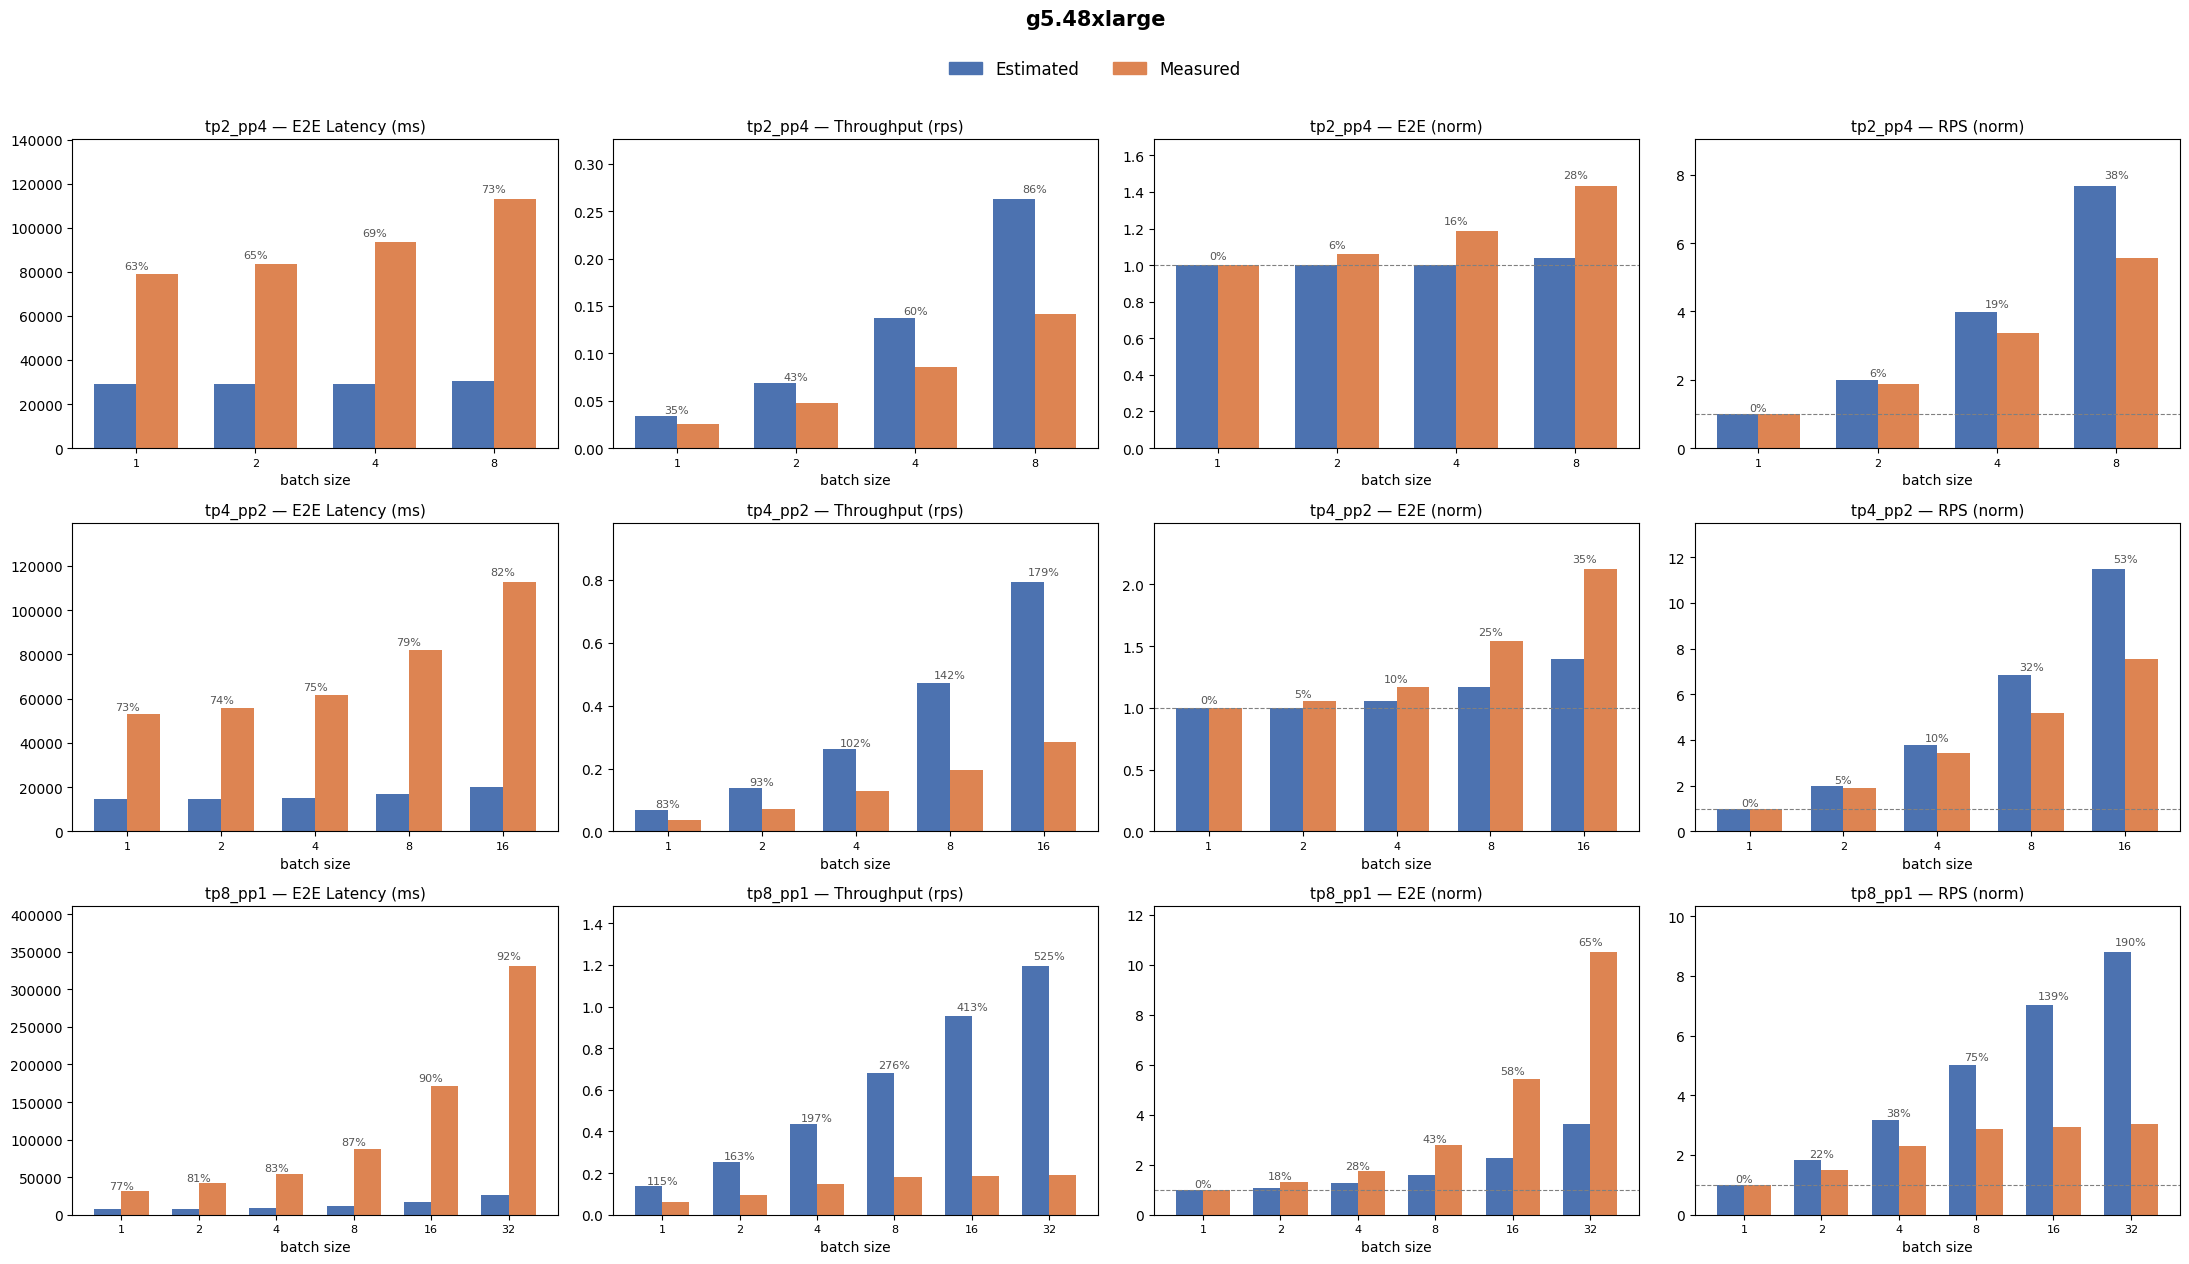

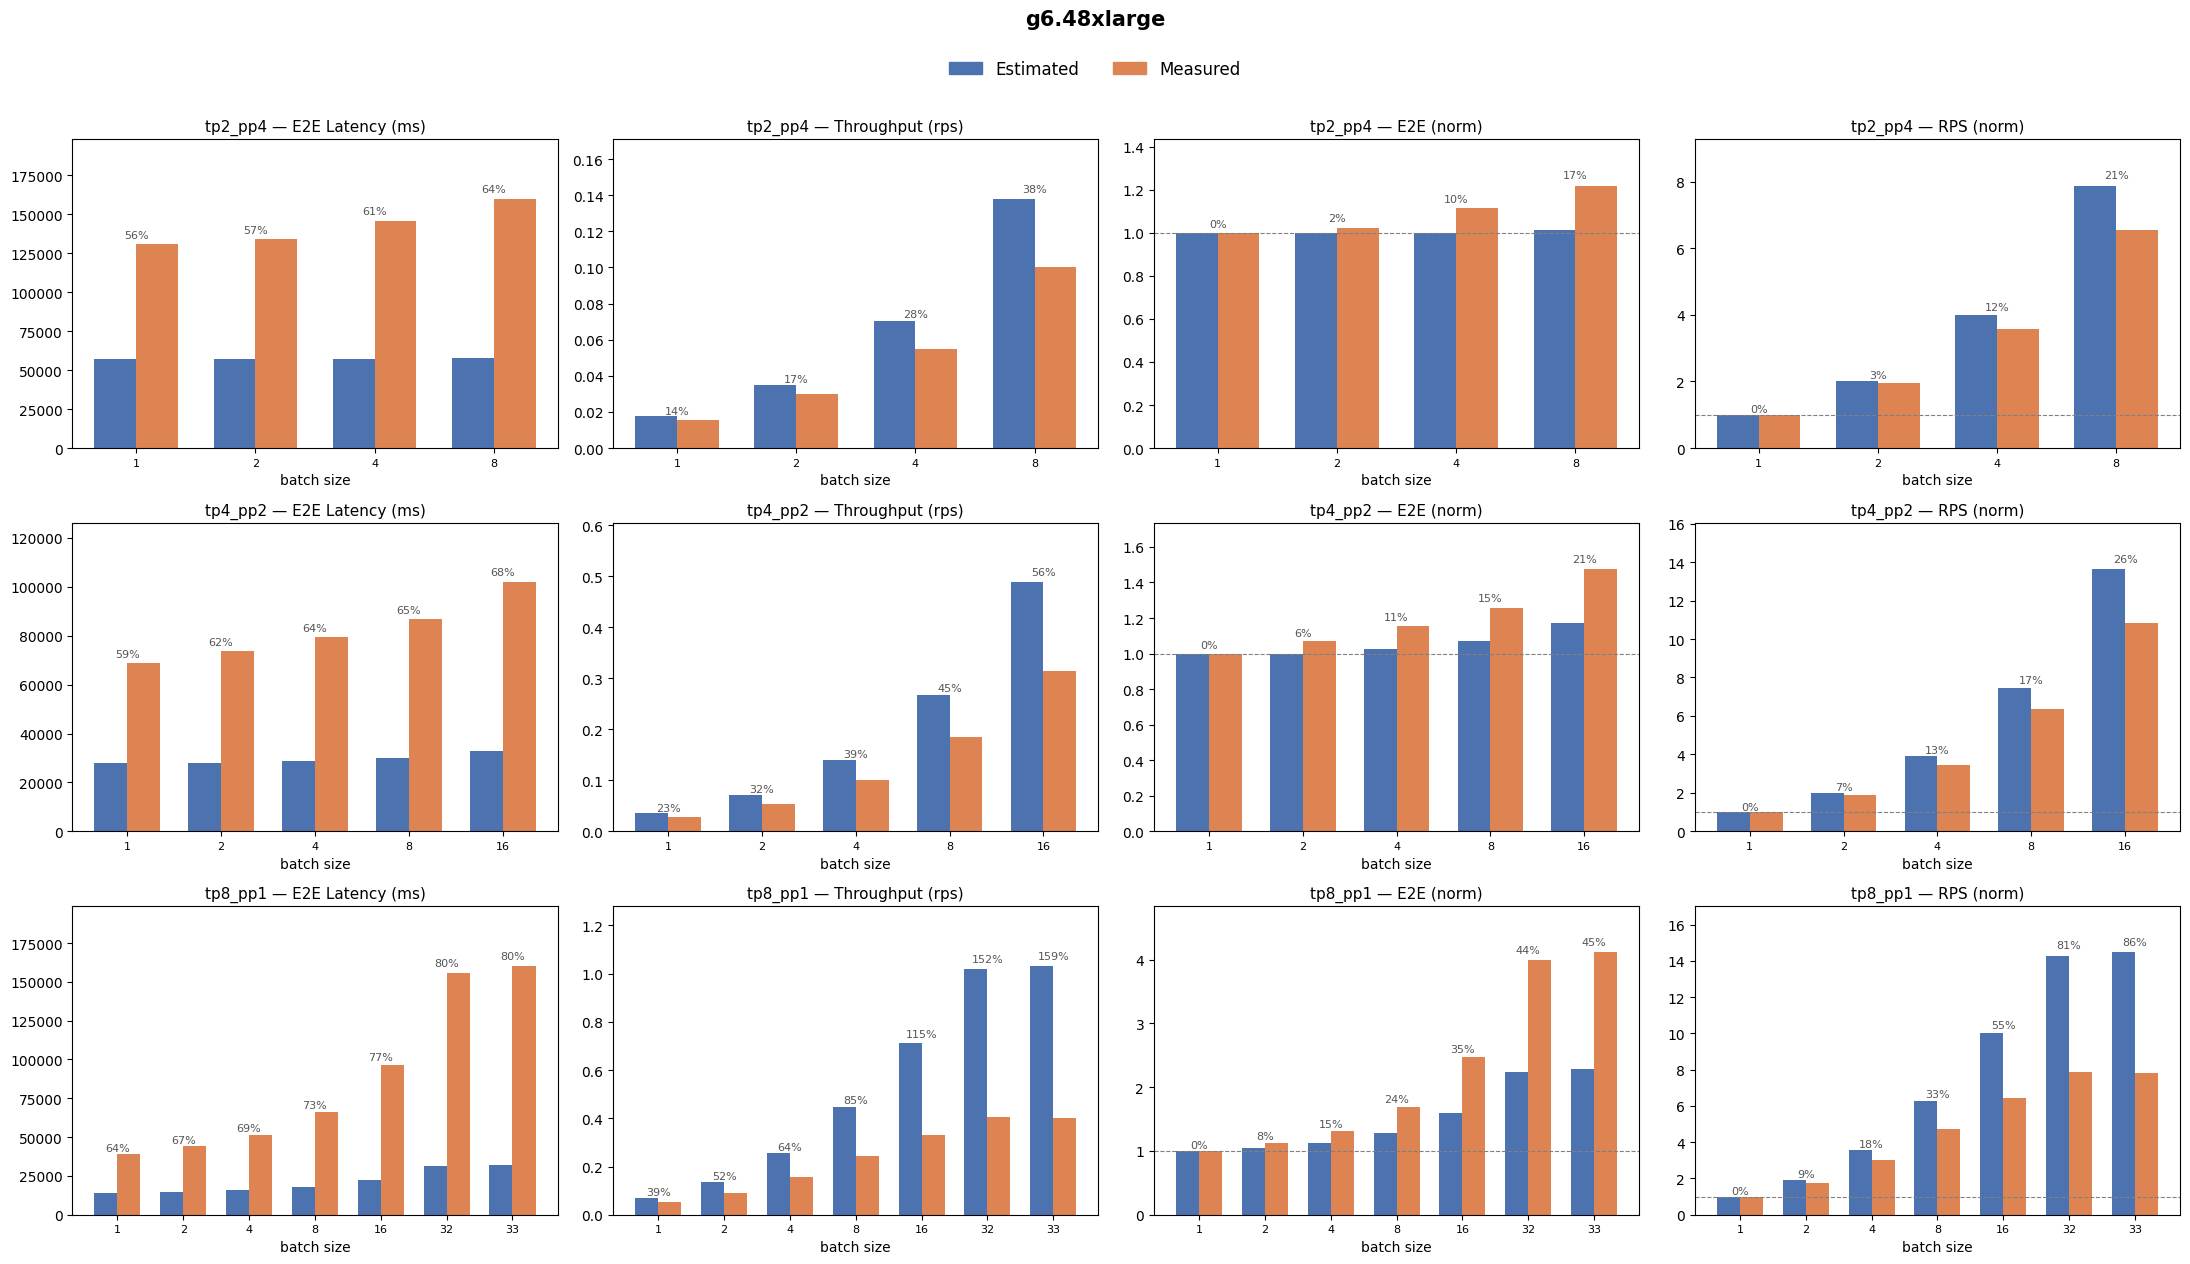

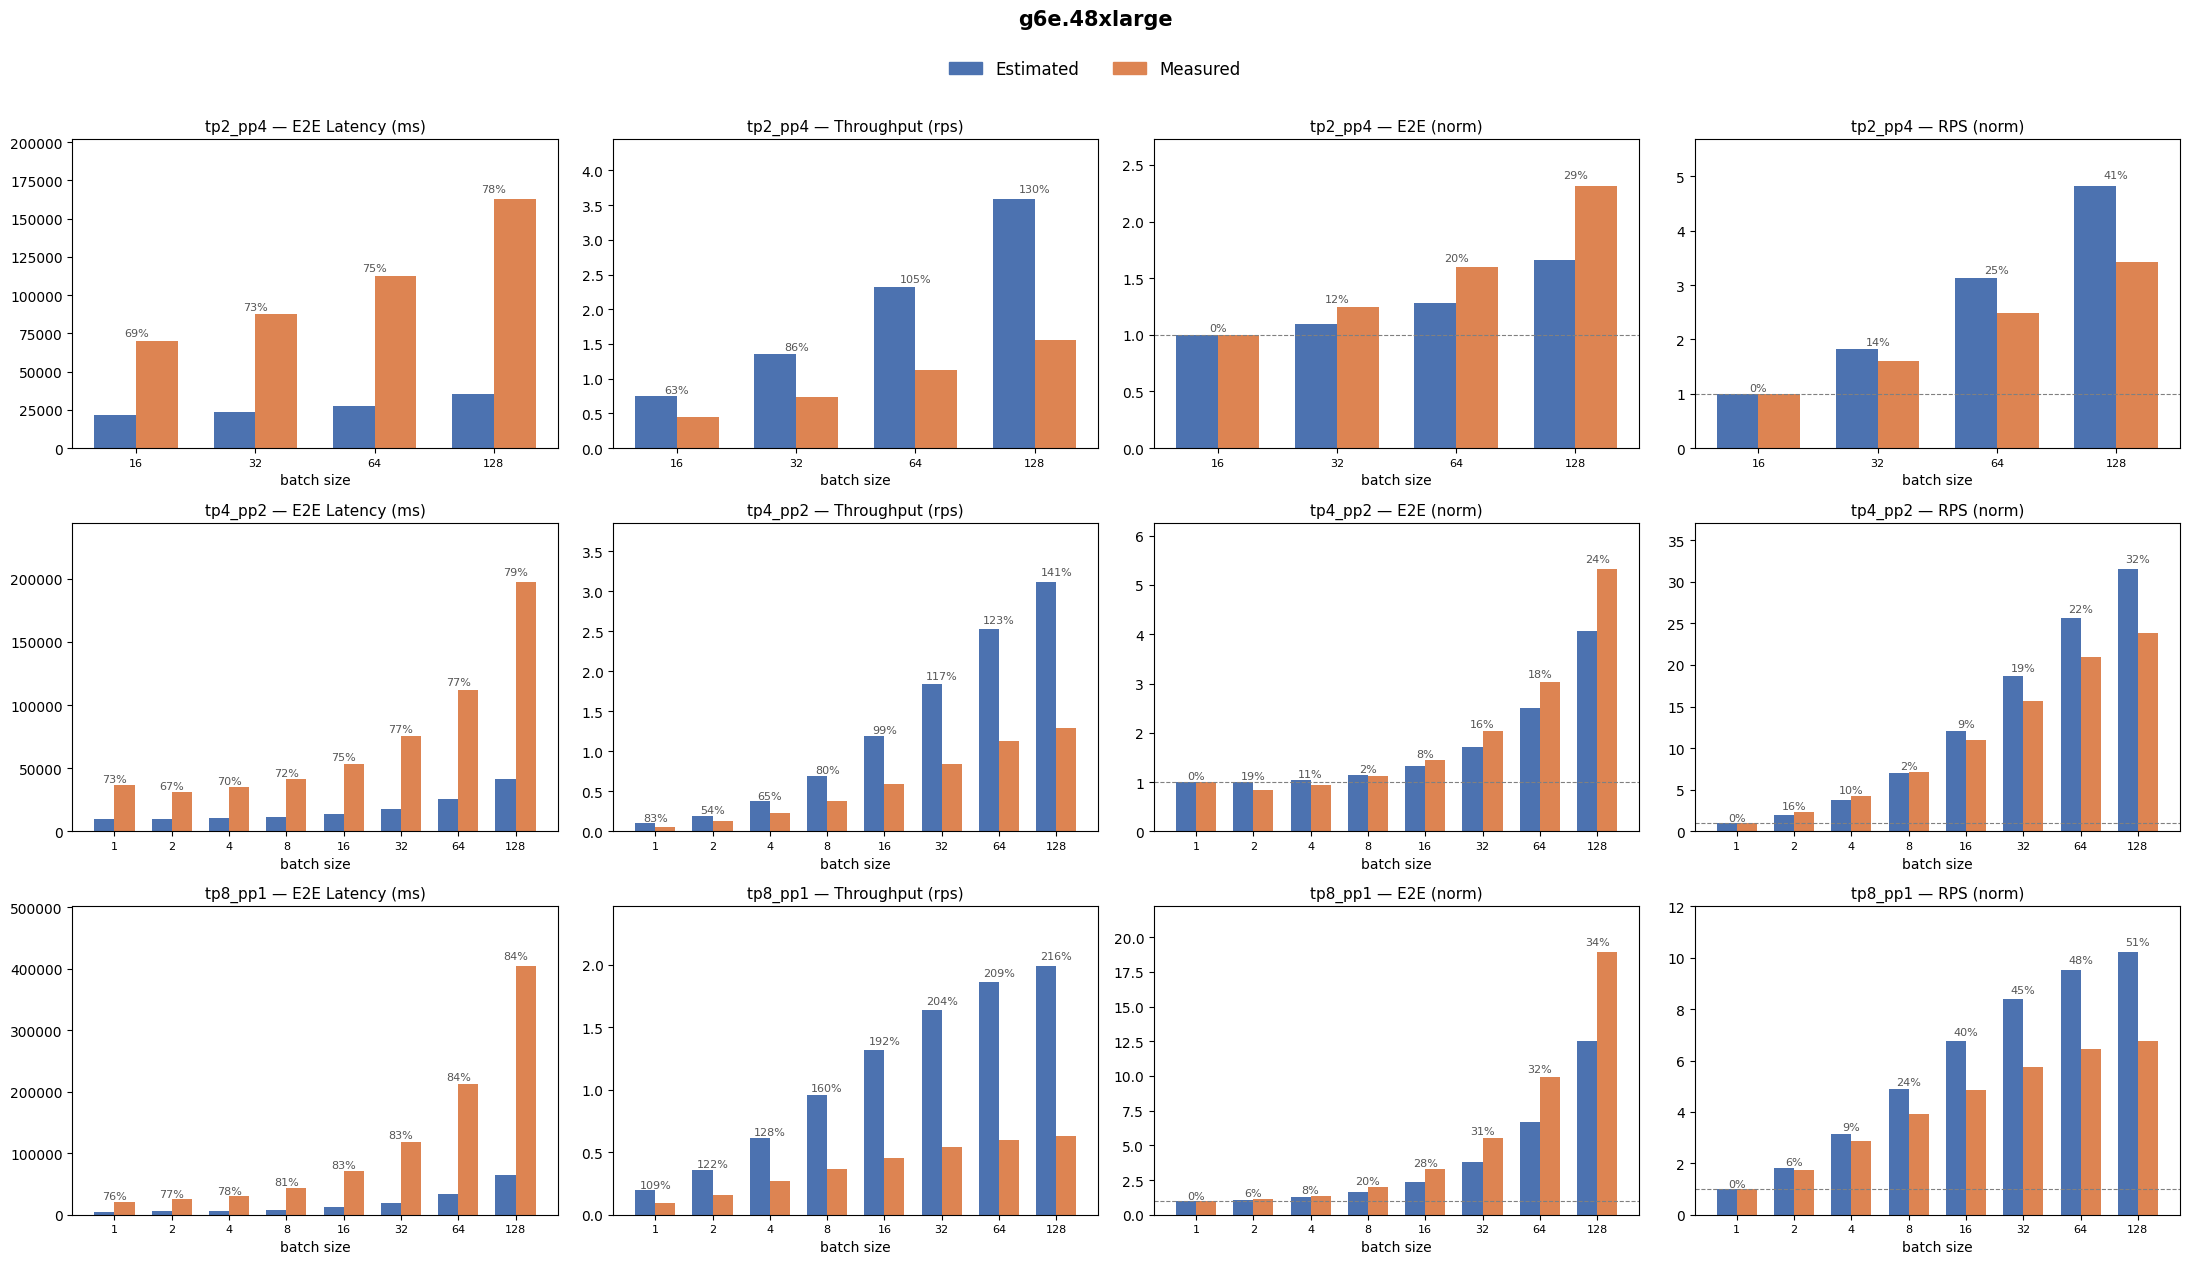

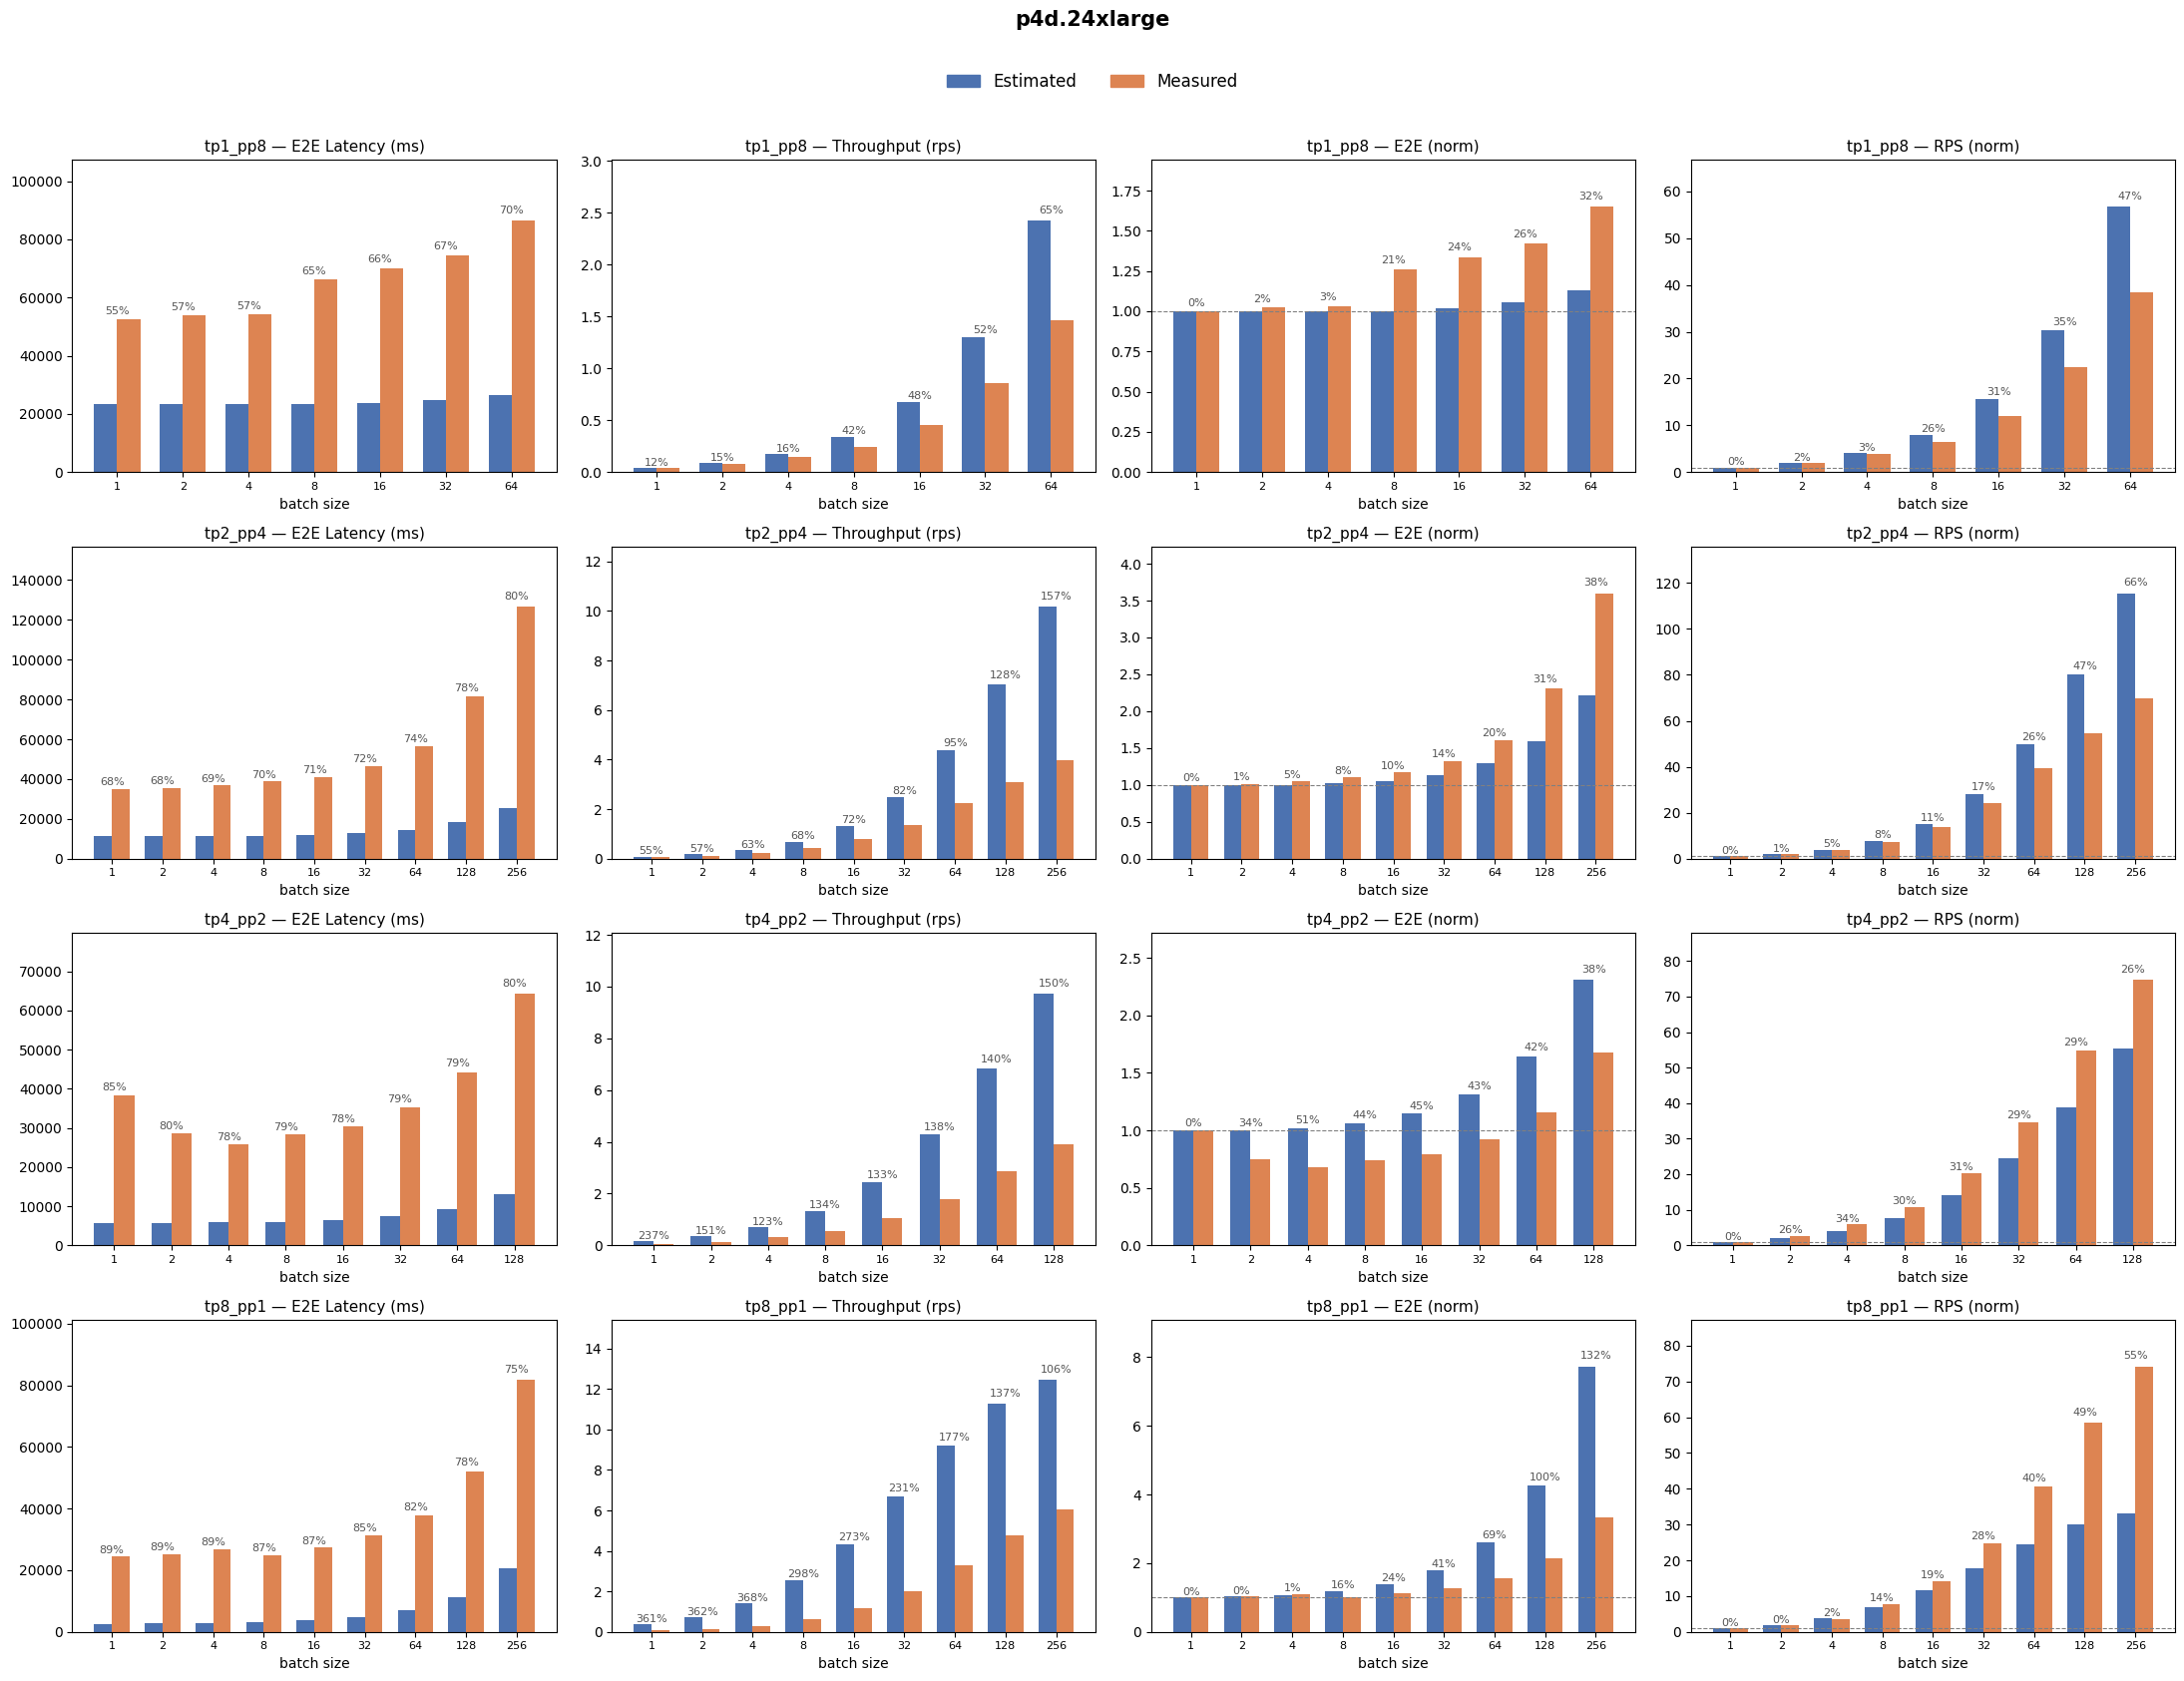

In [22]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_COLS = ["e2e_ms", "rps"]
PLOT_LABELS = {"e2e_ms": "E2E Latency (ms)", "rps": "Throughput (rps)"}
NORM_LABELS = {"e2e_ms": "E2E (norm)", "rps": "RPS (norm)"}
C_EST, C_MEAS = "#4C72B0", "#DD8452"

if not meas_df.empty:
    instances = merged["instance"].unique()

    for inst in instances:
        inst_df = merged[merged["instance"] == inst]
        strat_groups = list(inst_df.groupby(["tp", "pp"]))
        n_strats = len(strat_groups)

        fig, axes = plt.subplots(n_strats, 4, figsize=(22, 4 * n_strats))
        if n_strats == 1:
            axes = [axes]

        # Shared legend at top
        from matplotlib.patches import Patch
        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"{inst}", fontsize=15, fontweight="bold", y=1.05)

        for row, ((tp, pp), grp) in enumerate(strat_groups):
            grp = grp.sort_values("batch")
            batches = grp["batch"].values
            x = np.arange(len(batches))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"tp{tp}_pp{pp} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels([str(b) for b in batches], fontsize=8)
                ax_raw.set_xlabel("batch size")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to batch=1
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"tp{tp}_pp{pp} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels([str(b) for b in batches], fontsize=8)
                ax_norm.set_xlabel("batch size")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()


---
## 6. Cross-GPU Comparison (Fixed TP/PP/Batch)

Compare estimated vs measured across GPU instance types at the same parallelism strategy and batch size.
X-axis = instance type, bars = estimated vs measured.

Instances with tp=8, pp=1: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge', 'p4d.24xlarge']


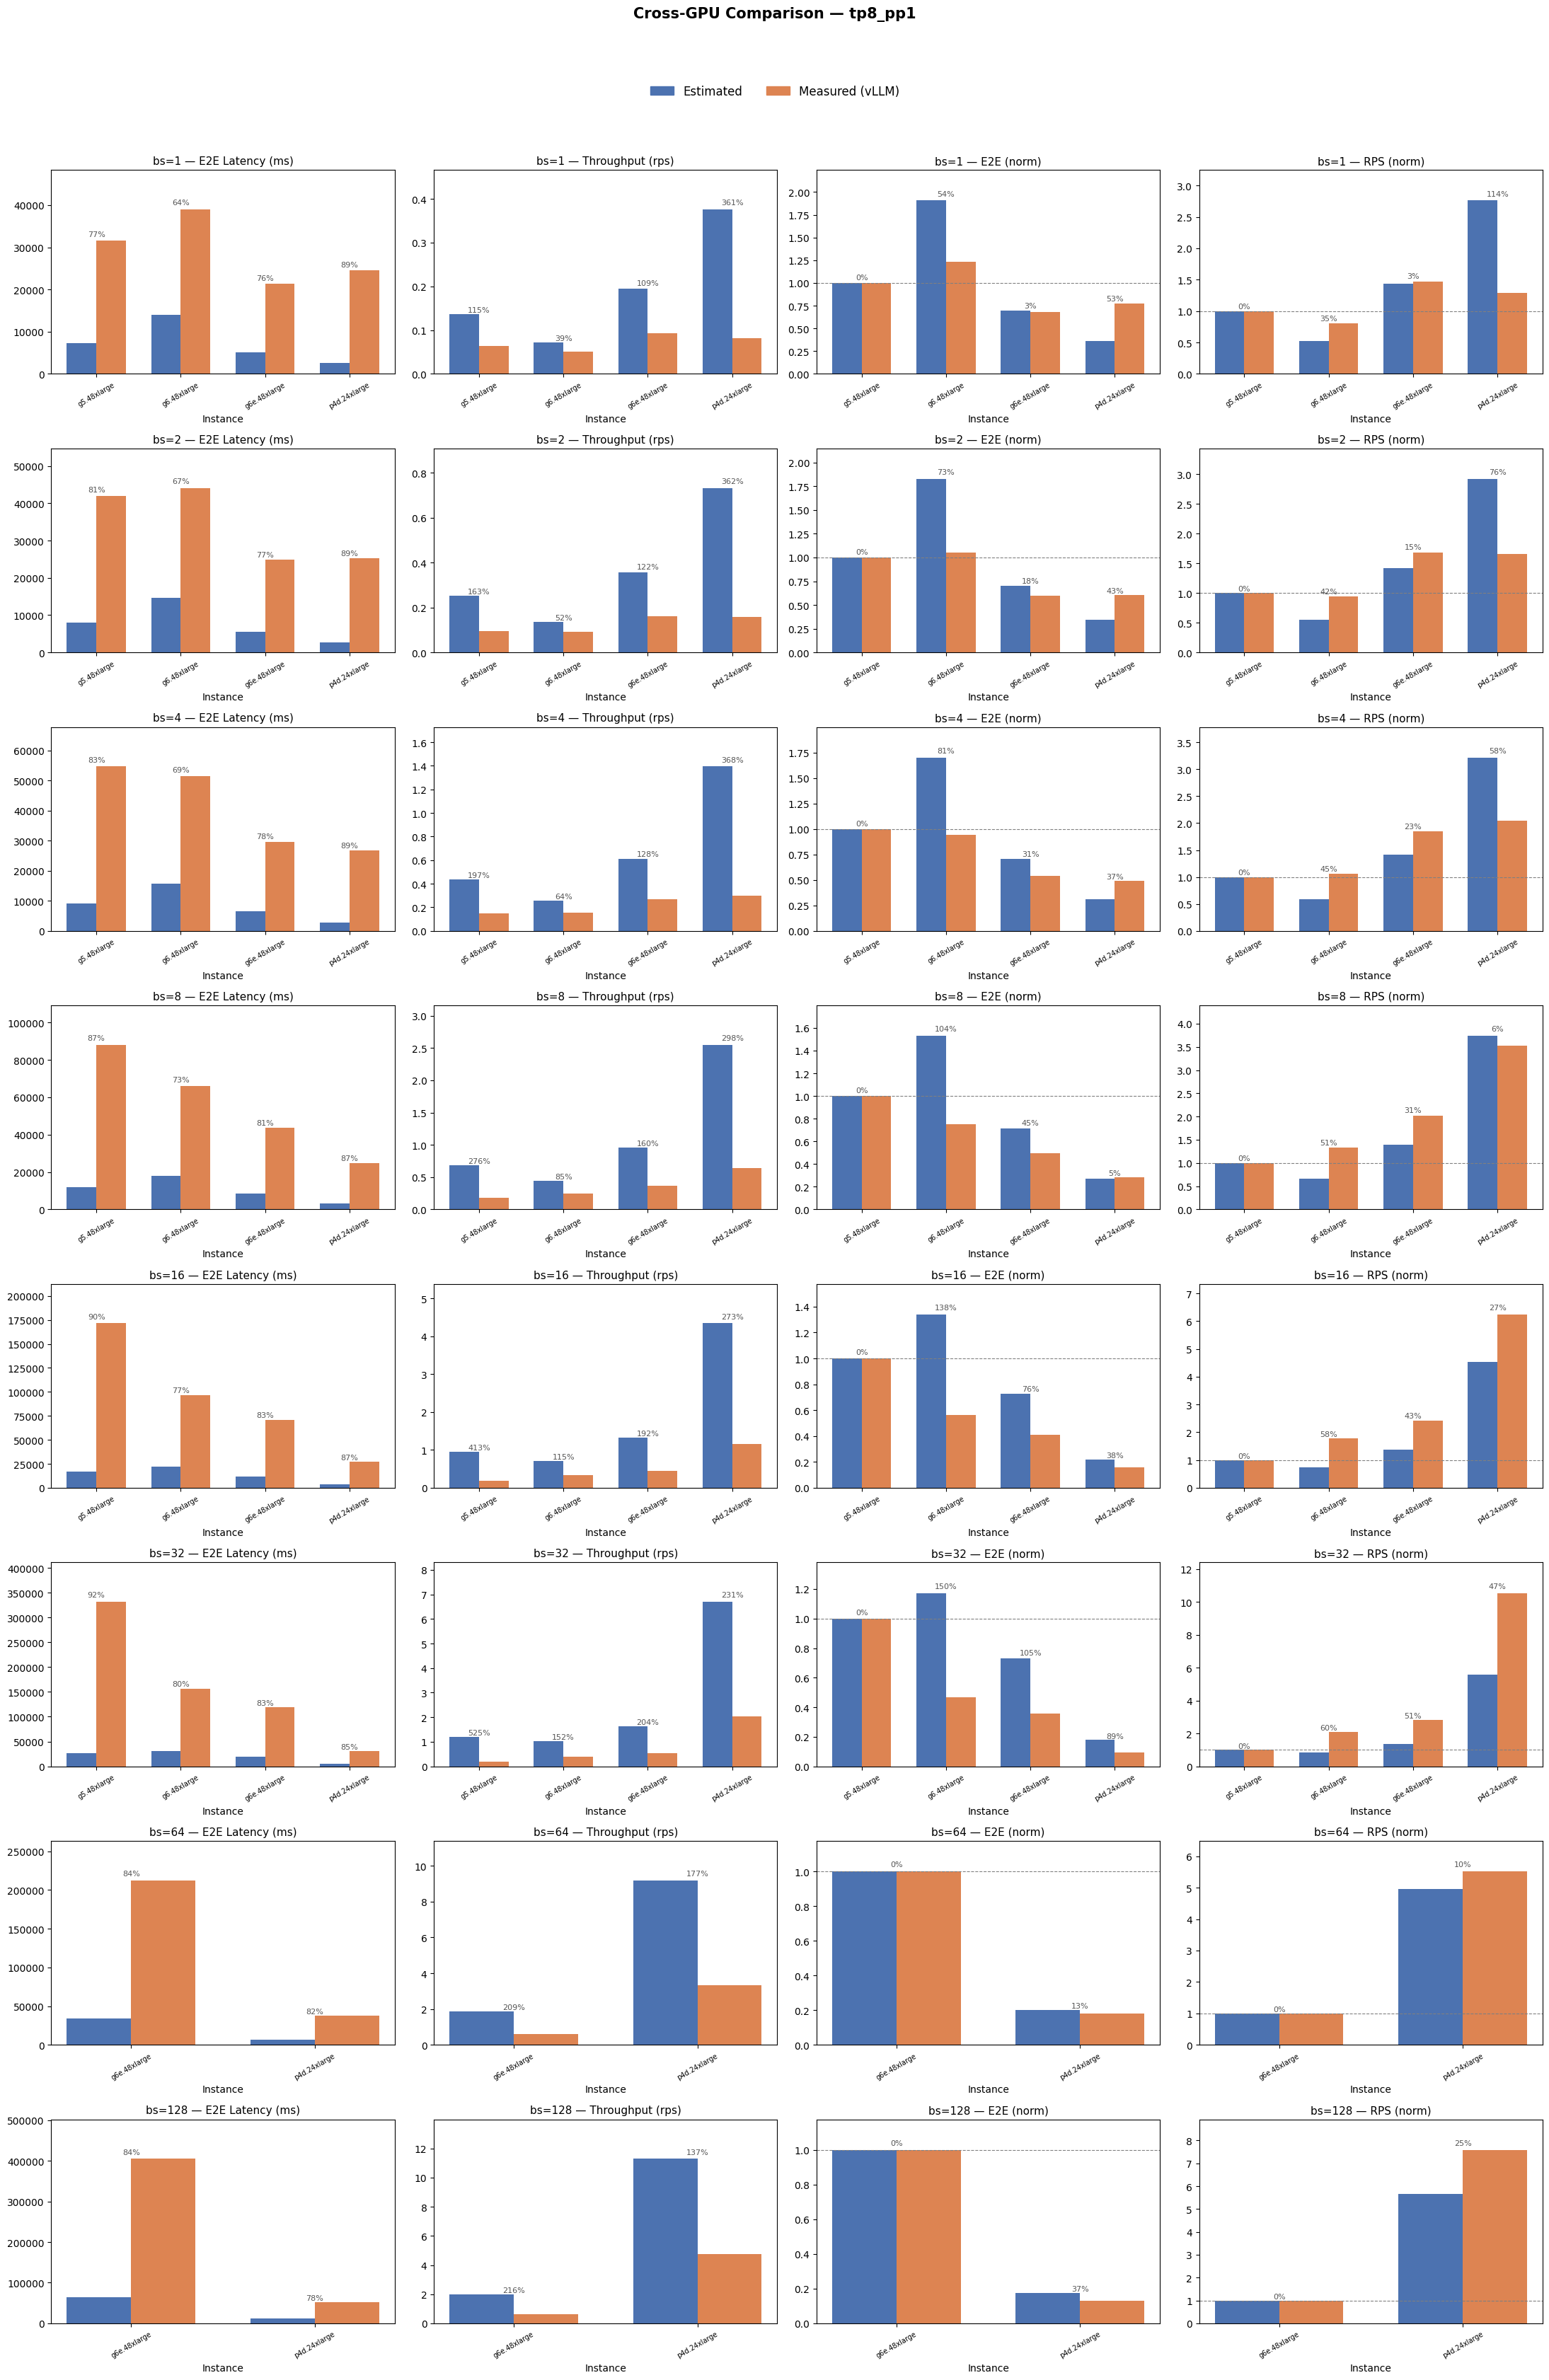

In [29]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 8
CROSS_PP = 1
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

Instances with tp=4, pp=2: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge', 'p4d.24xlarge']


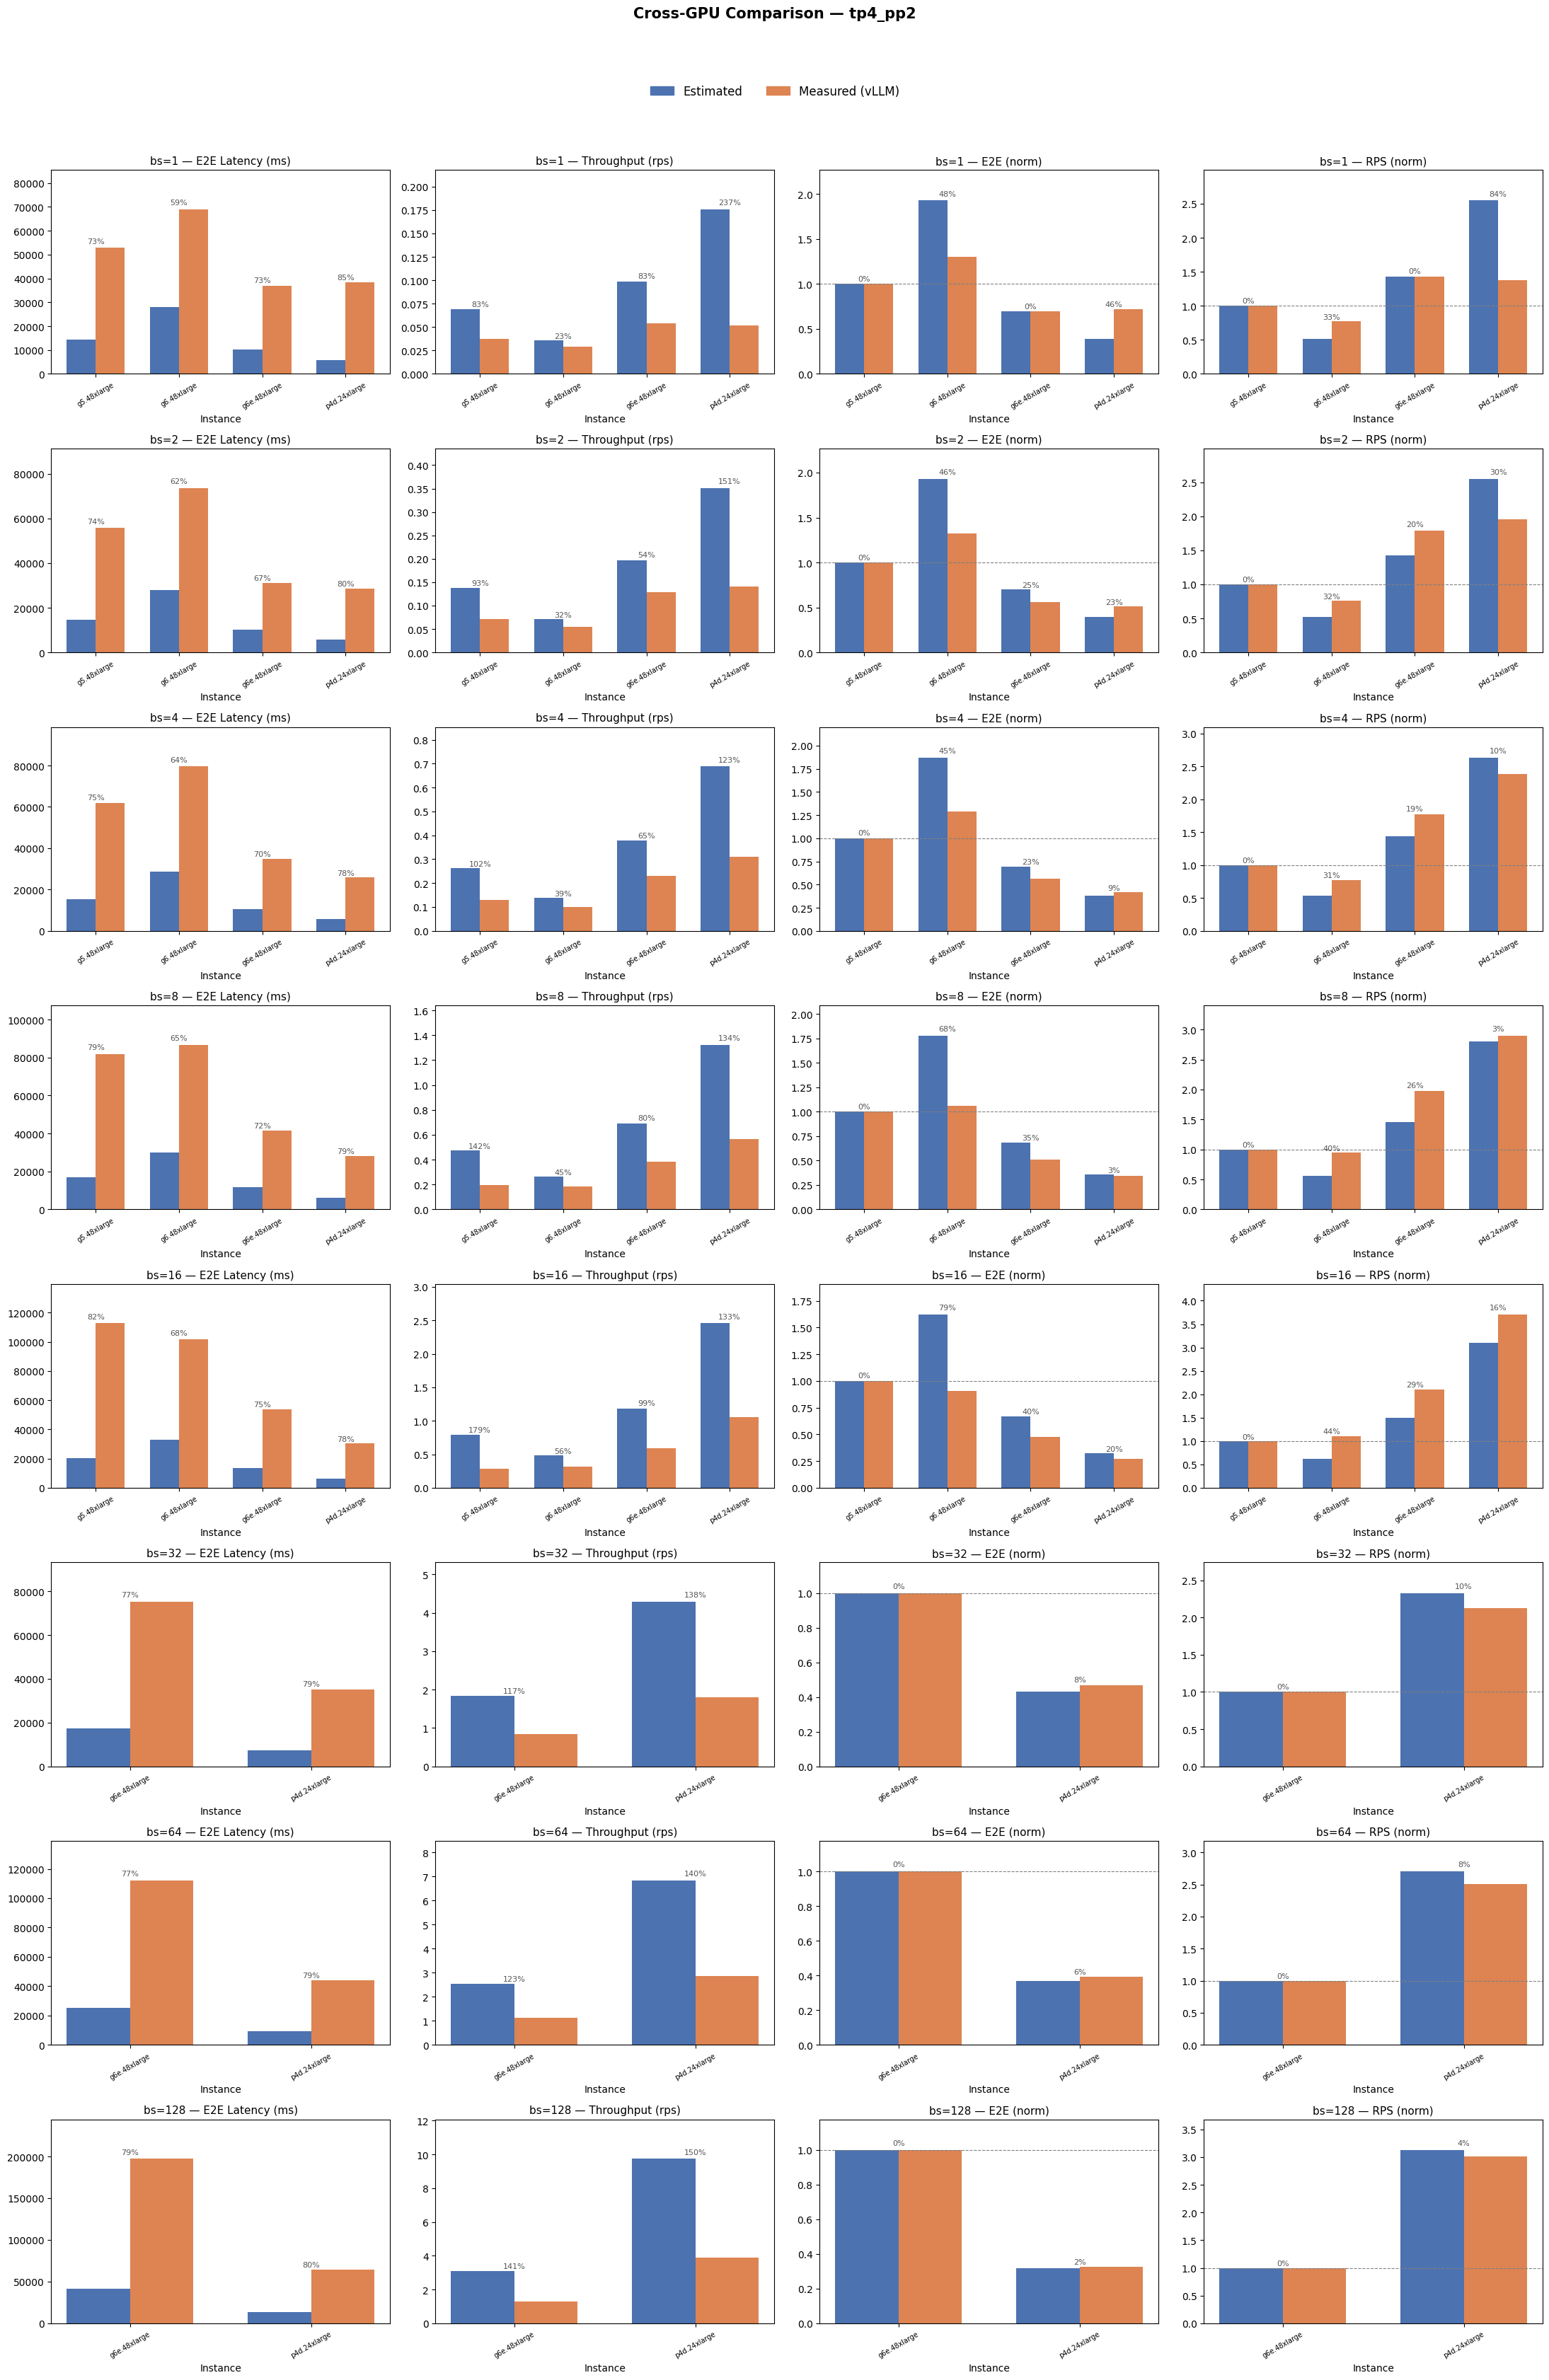

In [30]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 4
CROSS_PP = 2
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

Instances with tp=2, pp=4: ['g5.48xlarge', 'g6.48xlarge', 'g6e.48xlarge', 'p4d.24xlarge']


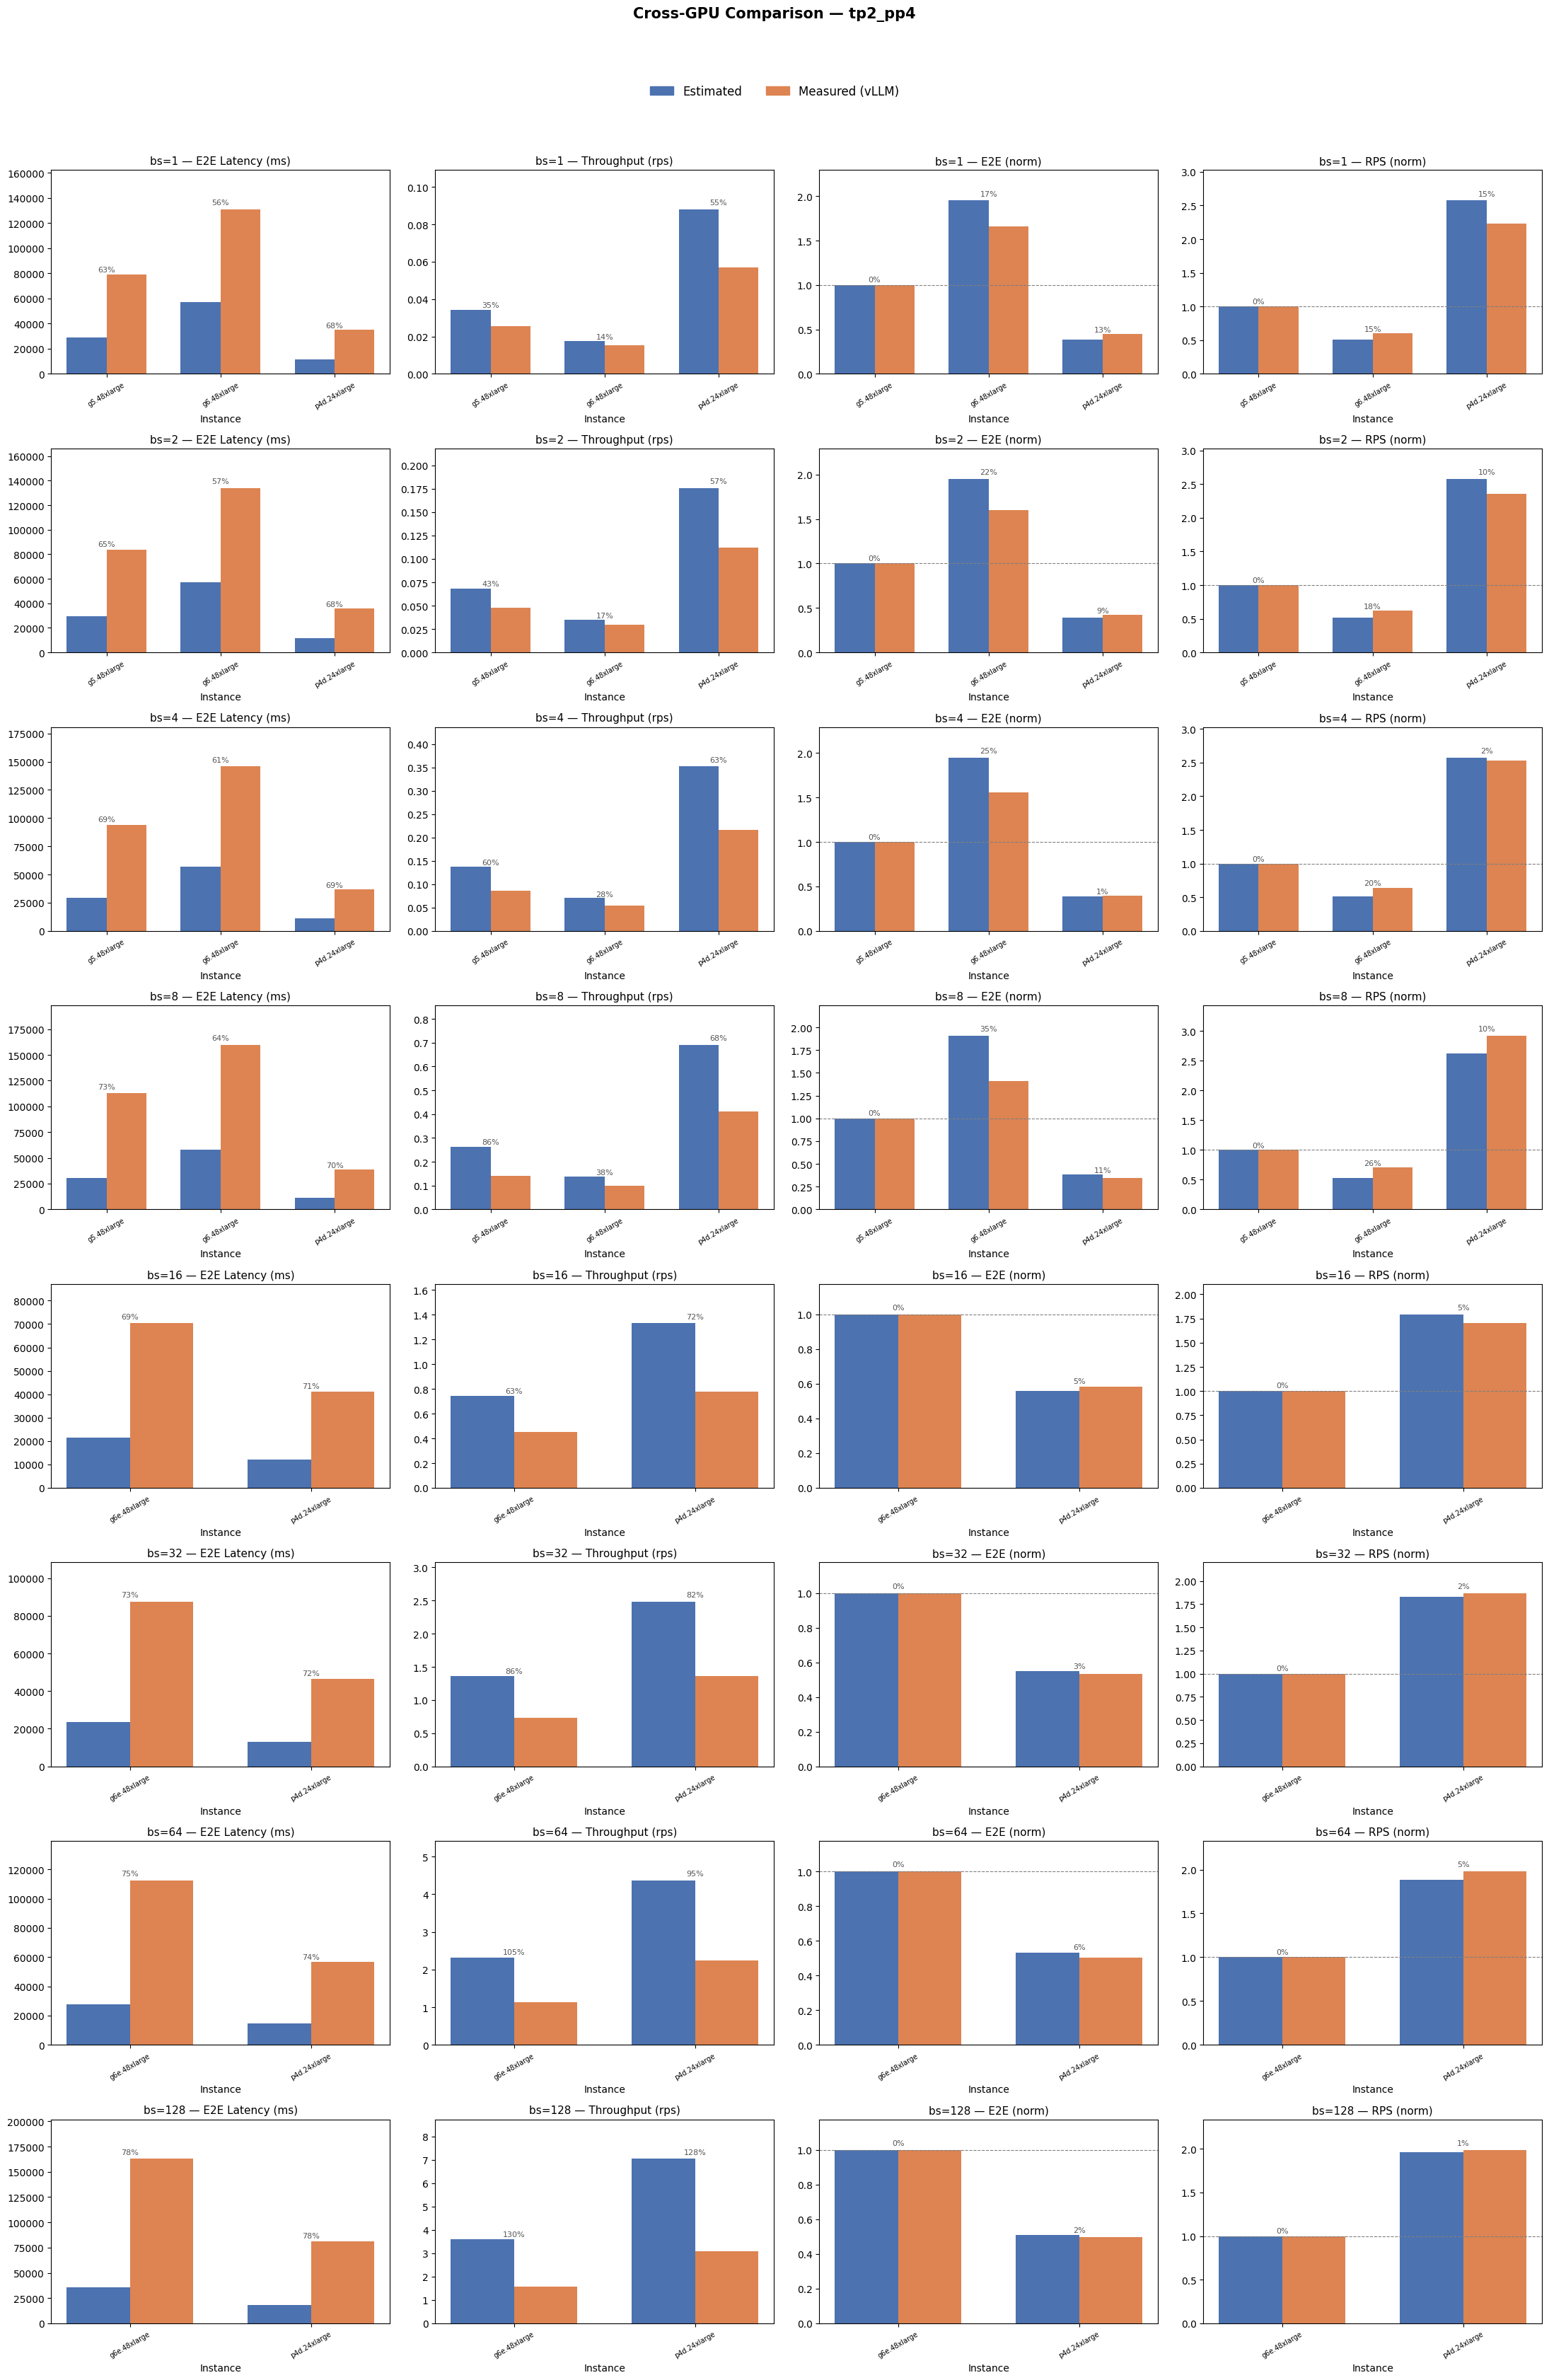

In [31]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 2
CROSS_PP = 4
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

In [32]:
# ─── Cross-GPU bar chart ─────────────────────────────────────────
CROSS_TP = 1
CROSS_PP = 8
CROSS_BATCH_SIZES = [1, 2, 4, 8, 16, 32, 64, 128]  # batch sizes to compare across GPUs
# ─────────────────────────────────────────────────────────────────

if not meas_df.empty:
    cross_merged = merged.copy()
    cross_merged = cross_merged[
        (cross_merged["tp"] == CROSS_TP) & (cross_merged["pp"] == CROSS_PP)
    ]
    cross_merged = cross_merged[cross_merged["batch"].isin(CROSS_BATCH_SIZES)]
    cross_merged = cross_merged.sort_values(["batch", "instance"]).reset_index(drop=True)

    avail_instances = sorted(cross_merged["instance"].unique())
    print(f"Instances with tp={CROSS_TP}, pp={CROSS_PP}: {avail_instances}")

    if len(avail_instances) < 2:
        print(f"Need >= 2 instances for cross-GPU comparison, got {len(avail_instances)}")
    elif cross_merged.empty:
        print(f"No matching data for tp={CROSS_TP}, pp={CROSS_PP}, batches={CROSS_BATCH_SIZES}")
    else:
        n_batches = cross_merged["batch"].nunique()
        fig, axes = plt.subplots(n_batches, 4, figsize=(22, 4 * n_batches))
        if n_batches == 1:
            axes = [axes]

        fig.legend(
            handles=[Patch(color=C_EST, label="Estimated"), Patch(color=C_MEAS, label="Measured (vLLM)")],
            loc="upper center", ncol=2, fontsize=12, frameon=False,
            bbox_to_anchor=(0.5, 1.02),
        )
        fig.suptitle(f"Cross-GPU Comparison — tp{CROSS_TP}_pp{CROSS_PP}", fontsize=15, fontweight="bold", y=1.05)

        for row, (bs, grp) in enumerate(cross_merged.groupby("batch")):
            grp = grp.sort_values("instance")
            instances = grp["instance"].values
            x = np.arange(len(instances))
            w = 0.35

            for ci, c in enumerate(PLOT_COLS):
                est_vals = grp[f"{c}_est"].values.astype(float)
                meas_vals = grp[f"{c}_meas"].values.astype(float)
                mape_vals = (abs(est_vals - meas_vals) / abs(meas_vals).clip(min=1e-9) * 100)

                # Raw
                ax_raw = axes[row][ci]
                be = ax_raw.bar(x - w/2, est_vals, w, color=C_EST)
                bm = ax_raw.bar(x + w/2, meas_vals, w, color=C_MEAS)
                for i, mp in enumerate(mape_vals):
                    top = max(be[i].get_height(), bm[i].get_height())
                    ax_raw.text(i, top * 1.02, f"{mp:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_raw.set_title(f"bs={bs} — {PLOT_LABELS[c]}", fontsize=11)
                ax_raw.set_xticks(x)
                ax_raw.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_raw.set_xlabel("Instance")
                ax_raw.set_ylim(0, ax_raw.get_ylim()[1] * 1.18)

                # Normalized to first instance
                ax_norm = axes[row][ci + 2]
                base_est = est_vals[0] if est_vals[0] != 0 else 1
                base_meas = meas_vals[0] if meas_vals[0] != 0 else 1
                norm_est = est_vals / base_est
                norm_meas = meas_vals / base_meas
                norm_mape = abs(norm_est - norm_meas) / abs(norm_meas).clip(min=1e-9) * 100
                be2 = ax_norm.bar(x - w/2, norm_est, w, color=C_EST)
                bm2 = ax_norm.bar(x + w/2, norm_meas, w, color=C_MEAS)
                for i, d in enumerate(norm_mape):
                    top = max(be2[i].get_height(), bm2[i].get_height())
                    ax_norm.text(i, top * 1.02, f"{d:.0f}%", ha="center", va="bottom", fontsize=8, color="#555")
                ax_norm.set_title(f"bs={bs} — {NORM_LABELS[c]}", fontsize=11)
                ax_norm.set_xticks(x)
                ax_norm.set_xticklabels(instances, fontsize=7, rotation=30)
                ax_norm.set_xlabel("Instance")
                ax_norm.axhline(y=1, color="gray", linestyle="--", linewidth=0.8)
                ax_norm.set_ylim(0, ax_norm.get_ylim()[1] * 1.12)

        plt.tight_layout()
        plt.show()

Instances with tp=1, pp=8: ['p4d.24xlarge']
Need >= 2 instances for cross-GPU comparison, got 1


---
## 4. Filter

In [24]:
filter_df(est_df, instance="g5.48xlarge", tp=2, pp=4)

,instance,tp,pp,batch,ttft_ms,tpot_ms,e2e_ms,rps
0,g5.48xlarge,2,4,1,1038.91,121.6562,29263.15,0.0342
1,g5.48xlarge,2,4,2,1038.91,60.8281,29263.15,0.0683
2,g5.48xlarge,2,4,4,1038.91,30.4140,29263.15,0.1367
3,g5.48xlarge,2,4,8,2077.83,15.2778,30433.51,0.2629
4,g5.48xlarge,2,4,11,2857.01,11.1498,31311.29,0.3513


In [25]:
filter_df(summary, instance="g6.48xlarge", tp=2, pp=4)

,instance,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,g6.48xlarge,2,4,1,700.53,1462.53,52.10,243.0029,560.6541,56.66,57077.21,130973.62,56.42,0.0175,0.0153,14.38
1,g6.48xlarge,2,4,2,700.53,2521.80,72.22,121.5015,569.9779,78.68,57077.21,134186.70,57.46,0.0350,0.0298,17.45
2,g6.48xlarge,2,4,4,700.53,2402.85,70.85,60.7507,621.1485,90.22,57077.21,145888.14,60.88,0.0701,0.0548,27.92
3,g6.48xlarge,2,4,8,1401.06,4757.32,70.55,30.4783,671.1135,95.46,57968.87,159784.54,63.72,0.1380,0.1001,37.86


In [26]:
filter_df(summary, instance="g6.48xlarge")

,instance,tp,pp,batch,ttft_ms_est,ttft_ms_meas,ttft_ms_mape%,tpot_ms_est,tpot_ms_meas,tpot_ms_mape%,e2e_ms_est,e2e_ms_meas,e2e_ms_mape%,rps_est,rps_meas,rps_mape%
0,g6.48xlarge,2,4,1,700.53,1462.53,52.10,243.0029,560.6541,56.66,57077.21,130973.62,56.42,0.0175,0.0153,14.38
1,g6.48xlarge,2,4,2,700.53,2521.80,72.22,121.5015,569.9779,78.68,57077.21,134186.70,57.46,0.0350,0.0298,17.45
2,g6.48xlarge,2,4,4,700.53,2402.85,70.85,60.7507,621.1485,90.22,57077.21,145888.14,60.88,0.0701,0.0548,27.92
3,g6.48xlarge,2,4,8,1401.06,4757.32,70.55,30.4783,671.1135,95.46,57968.87,159784.54,63.72,0.1380,0.1001,37.86
4,g6.48xlarge,4,2,1,530.80,1052.98,49.59,118.2489,293.9695,59.78,27964.54,68959.94,59.45,0.0358,0.0290,23.45
5,g6.48xlarge,4,2,2,530.80,1867.37,71.57,59.1244,311.0278,80.99,27964.54,73714.78,62.06,0.0715,0.0542,31.92
6,g6.48xlarge,4,2,4,1061.59,2207.49,51.91,29.7276,335.1103,91.13,28648.82,79617.98,64.02,0.1396,0.1004,39.04
7,g6.48xlarge,4,2,8,2123.19,4101.07,48.23,15.0292,357.6108,95.80,30017.38,86709.17,65.38,0.2665,0.1844,44.52
8,g6.48xlarge,4,2,16,4246.38,8148.55,47.89,7.6800,405.5404,98.11,32754.51,101828.39,67.83,0.4885,0.3139,55.62
9,g6.48xlarge,8,1,1,431.37,1304.68,66.94,58.4730,163.1168,64.15,13997.10,38984.66,64.10,0.0714,0.0513,39.18
